<a href="https://colab.research.google.com/github/sharvani1357/SVM/blob/main/svmloanprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

In [3]:
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [6]:


# Fill categorical nulls with mode
cat_cols = ['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical nulls with median
num_cols = ['LoanAmount']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Null values after filling:\n", df.isnull().sum())


Null values after filling:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [8]:
df.shape

(614, 13)

In [9]:
# Outlier removal using IQR method
outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after outlier removal:", df.shape)


Shape after outlier removal: (520, 13)


In [28]:
#Encode categorical variables
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Train SVM with Linear Kernel
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

In [32]:
print("Accuracy (Linear Kernel):", accuracy_score(y_test, y_pred_linear))
print("Classification Report (Linear Kernel):")
print(classification_report(y_test, y_pred_linear))

Accuracy (Linear Kernel): 0.8076923076923077
Classification Report (Linear Kernel):
              precision    recall  f1-score   support

           0       0.85      0.50      0.63        34
           1       0.80      0.96      0.87        70

    accuracy                           0.81       104
   macro avg       0.82      0.73      0.75       104
weighted avg       0.81      0.81      0.79       104



In [33]:
print("Confusion Matrix (Linear Kernel):")
print(confusion_matrix(y_test, y_pred_linear))

Confusion Matrix (Linear Kernel):
[[17 17]
 [ 3 67]]


In [34]:
# Train SVM with polynomial Kernel adding degree
svm_poly = SVC(kernel='poly',degree=3, C=1)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

In [35]:
print("accuracy polynomia kernel",accuracy_score(y_test,y_pred_poly))
print("Classification Report (Polynomial Kernel):")
print(classification_report(y_test, y_pred_poly))

accuracy polynomia kernel 0.7980769230769231
Classification Report (Polynomial Kernel):
              precision    recall  f1-score   support

           0       0.78      0.53      0.63        34
           1       0.80      0.93      0.86        70

    accuracy                           0.80       104
   macro avg       0.79      0.73      0.75       104
weighted avg       0.80      0.80      0.79       104



In [36]:
print("Confusion Matrix (poly Kernel):")
print(confusion_matrix(y_test, y_pred_poly))

Confusion Matrix (poly Kernel):
[[18 16]
 [ 5 65]]


In [37]:
#Train SVM with RBF kernel
svm_rbf=SVC(kernel='rbf',C=1,gamma='scale')
svm_rbf.fit(X_train,y_train)
y_pred_rbf=svm_rbf.predict(X_test)

In [38]:
print("accuracy rbf kernel",accuracy_score(y_test,y_pred_rbf))
print("Classification Report (RBF Kernel):")
print(classification_report(y_test, y_pred_rbf))

accuracy rbf kernel 0.8076923076923077
Classification Report (RBF Kernel):
              precision    recall  f1-score   support

           0       0.85      0.50      0.63        34
           1       0.80      0.96      0.87        70

    accuracy                           0.81       104
   macro avg       0.82      0.73      0.75       104
weighted avg       0.81      0.81      0.79       104



In [39]:
print("Confusion Matrix (RBF Kernel):")
print(confusion_matrix(y_test, y_pred_rbf))

Confusion Matrix (RBF Kernel):
[[17 17]
 [ 3 67]]


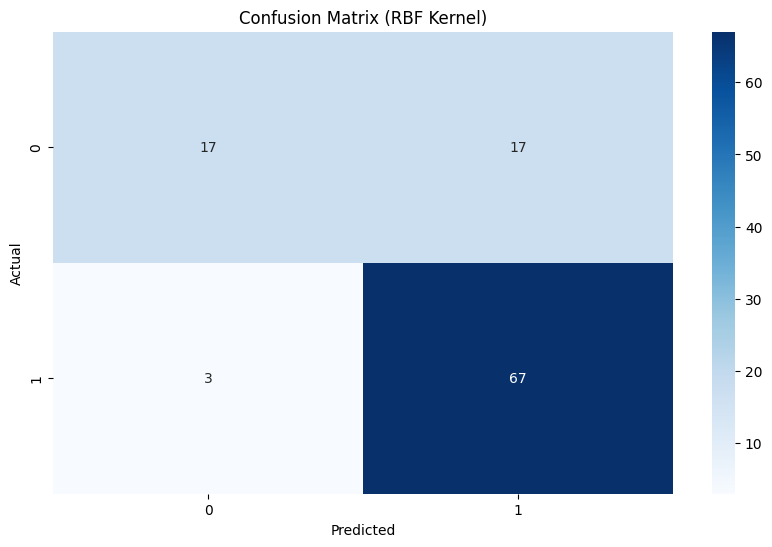

In [40]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


========== Kernel: LINEAR ==========
Train Accuracy: 0.8293269230769231
Test Accuracy : 0.8076923076923077

Confusion Matrix:
 [[17 17]
 [ 3 67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.50      0.63        34
           1       0.80      0.96      0.87        70

    accuracy                           0.81       104
   macro avg       0.82      0.73      0.75       104
weighted avg       0.81      0.81      0.79       104


========== Kernel: RBF ==========
Train Accuracy: 0.8341346153846154
Test Accuracy : 0.8076923076923077

Confusion Matrix:
 [[17 17]
 [ 3 67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.50      0.63        34
           1       0.80      0.96      0.87        70

    accuracy                           0.81       104
   macro avg       0.82      0.73      0.75       104
weighted avg       0.81      0.81      0.79       104


====

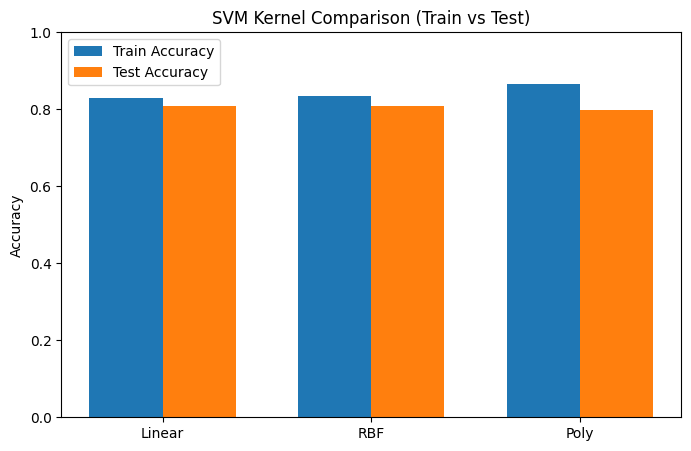

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

kernels = ['linear', 'rbf', 'poly']
train_acc = []
test_acc = []

models = {}

for k in kernels:
    svm = SVC(kernel=k, C=1, gamma='scale')
    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    tr = accuracy_score(y_train, y_train_pred)
    te = accuracy_score(y_test, y_test_pred)

    train_acc.append(tr)
    test_acc.append(te)

    models[k] = svm

    print(f"\n========== Kernel: {k.upper()} ==========")
    print("Train Accuracy:", tr)
    print("Test Accuracy :", te)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# ----------- Plot Train vs Test Accuracy -----------
x = np.arange(len(kernels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_acc, width, label="Train Accuracy")
plt.bar(x + width/2, test_acc, width, label="Test Accuracy")

plt.xticks(x, ["Linear", "RBF", "Poly"])
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison (Train vs Test)")
plt.legend()
plt.ylim(0, 1)
plt.show()


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)   # y_pred = model predictions
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:\n", cm)
print("\nEligible customers rejected (FN):", FN)
print("Risky customers approved (FP):", FP)


NameError: name 'y_pred' is not defined

In [45]:
from sklearn.metrics import confusion_matrix

# If not already done, create predictions
y_pred_linear = svm_linear.predict(X_test)

y_pred_poly = svm_poly.predict(X_test)

svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

preds = {
    "Linear": y_pred_linear,
    "Poly": y_pred_poly,
    "RBF": y_pred_rbf
}

for name, y_pred in preds.items():
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    print(f"\n====== {name} Kernel ======")
    print("Confusion Matrix:\n", cm)
    print("Eligible customers rejected (FN):", FN)
    print("Risky customers approved (FP):", FP)




====== Linear Kernel ======
Confusion Matrix:
 [[17 17]
 [ 3 67]]
Eligible customers rejected (FN): 3
Risky customers approved (FP): 17

====== Poly Kernel ======
Confusion Matrix:
 [[18 16]
 [ 5 65]]
Eligible customers rejected (FN): 5
Risky customers approved (FP): 16

====== RBF Kernel ======
Confusion Matrix:
 [[17 17]
 [ 3 67]]
Eligible customers rejected (FN): 3
Risky customers approved (FP): 17
